In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../signals/')
path.append('../wavelet/')
import signals as sg
import cwt_segmentation as cs
import wavelet_funcs as wf

In [3]:
from scipy.signal import periodogram

# AR(k=1)

In [75]:
fs = 25
T = 40
t = np.arange(0, T, 1/fs)

ps = dict(
    intercept = 0,
    ar_coeffs = [0.9],
    noise_std = 1,
)
s = cs.simulate_ar_surrogate(ps, n=t.size)
s = s + 3*np.cos(2*np.pi* 0.75*t)

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

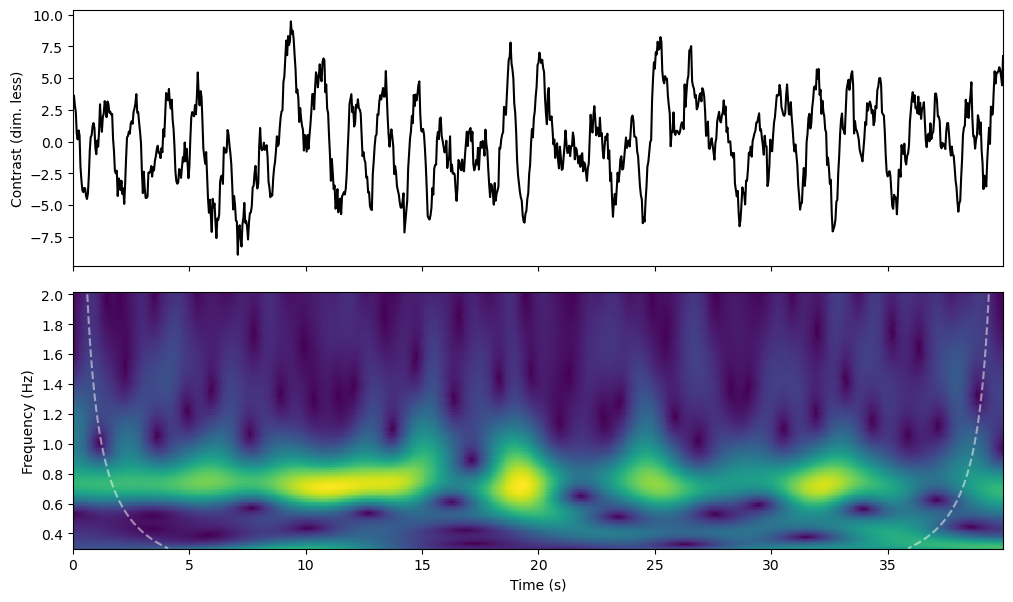

In [76]:
wf.plot_timeseries_and_its_cwt(s, t, 0.3, 2, show_smoothed=False, padding_fraction=0.2)

## Fit AR1 to raw data and show the result — AR1 model describes everything, including the oscillations

In [77]:
res = cs.fit_ar_model(s, 1)

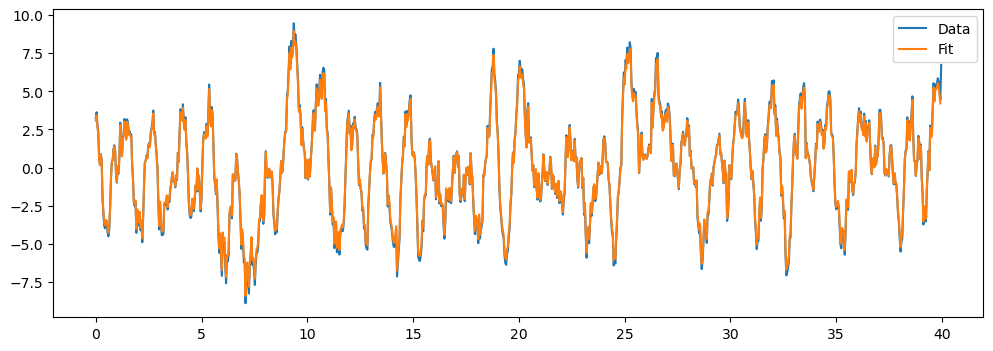

In [78]:
plt.figure(figsize=(12,4))
plt.plot(t,s, label='Data')
plt.plot(t[:-1],res['result'].fittedvalues, label='Fit')
plt.legend()

## Fit AR1 to raw data after filtering the oscillation band. and show the result

In [79]:
s_filt = cs.remove_frequency_band(s, fs, 0.6, 0.9)
# s_filt = wf.gaussian_filter(s, sigma=25)
res = cs.fit_ar_model(s_filt, 1)

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

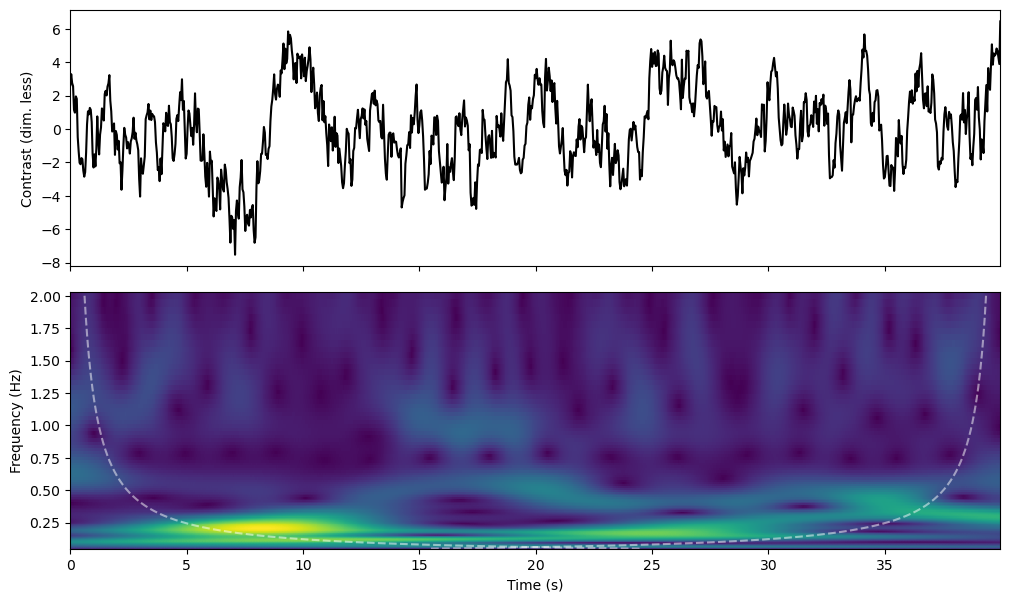

In [80]:
wf.plot_timeseries_and_its_cwt(s_filt, t, 0.05, 2, show_smoothed=False)

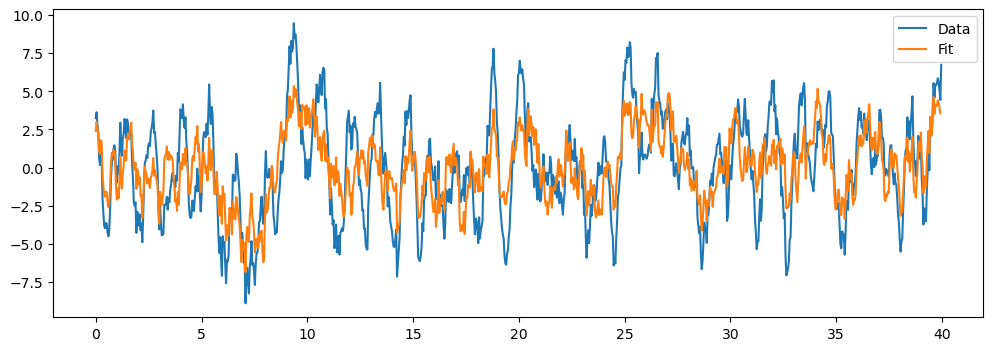

In [81]:
plt.figure(figsize=(12,4))
plt.plot(t,s, label='Data')
plt.plot(t[:-1],res['result'].fittedvalues, label='Fit')
plt.legend()

In [ ]:
s_filt = cs.remove_frequency_band(s, fs, 0.5, 1)

In [130]:
res = cs.fit_ar_model(s_filt, 1)

In [131]:
res

{'result': <statsmodels.tsa.ar_model.AutoRegResultsWrapper at 0x336545110>,
 'intercept': 0.01944525765782325,
 'ar_coeffs': array([0.65232416]),
 'noise_std': 1.0337268394419747,
 'order': 1}

In [132]:
freqs = np.linspace(0.05, 2, 128)
power, _, scales = cs.compute_cwt_power(s, fs, freqs)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

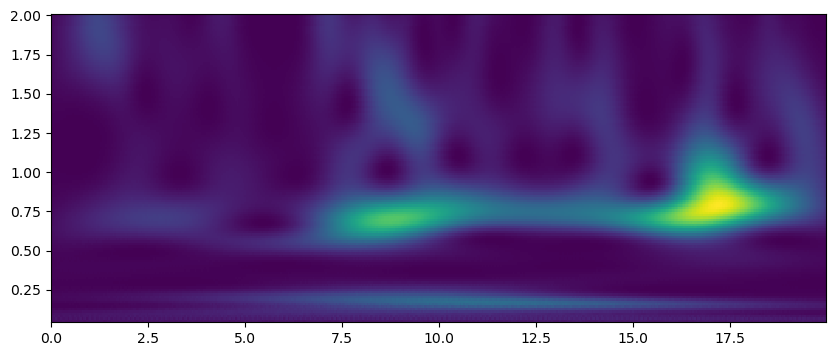

In [133]:
wf.plot_cwt(power, freqs, t)

In [134]:
threshold = cs.monte_carlo_cwt_threshold(
        res,
        n=len(t),
        fs=fs,
        freqs=freqs,
    )

In [135]:
significant = cs.segment_significant_power(power, threshold)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

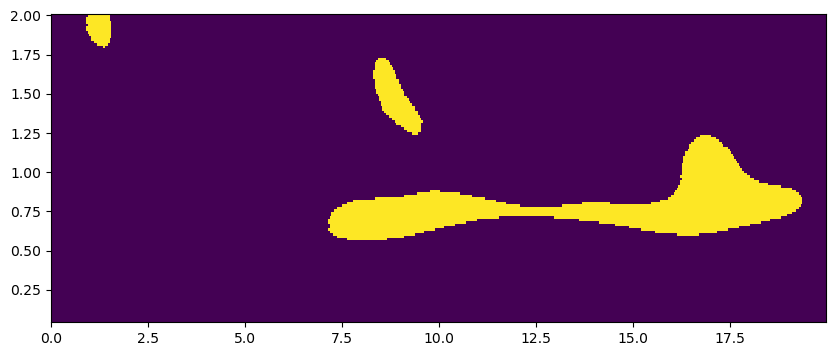

In [136]:
wf.plot_cwt(significant, freqs, t)

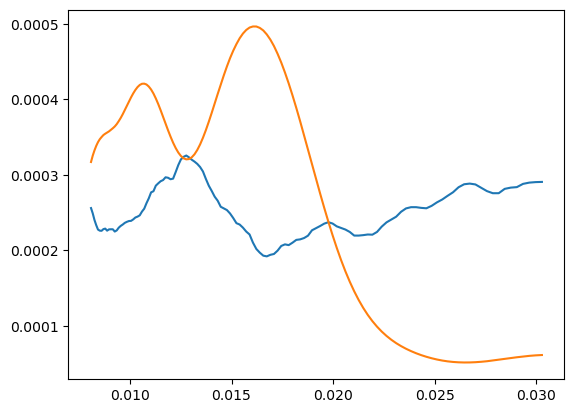

In [ ]:
plt.plot(freqs, threshold)
plt.plot(freqs, power.mean(axis=1))


# AR(k=2), but fit AR(k=1)

In [357]:
fs = 25
T = 20
t = np.arange(0, T, 1/fs)

ps = dict(
    intercept = 0,
    ar_coeffs = [0.55, 0.1],
    noise_std = 1,
)
s = cs.simulate_ar_surrogate(ps, n=t.size)
s = s + np.cos(2*np.pi* 0.75*t)

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

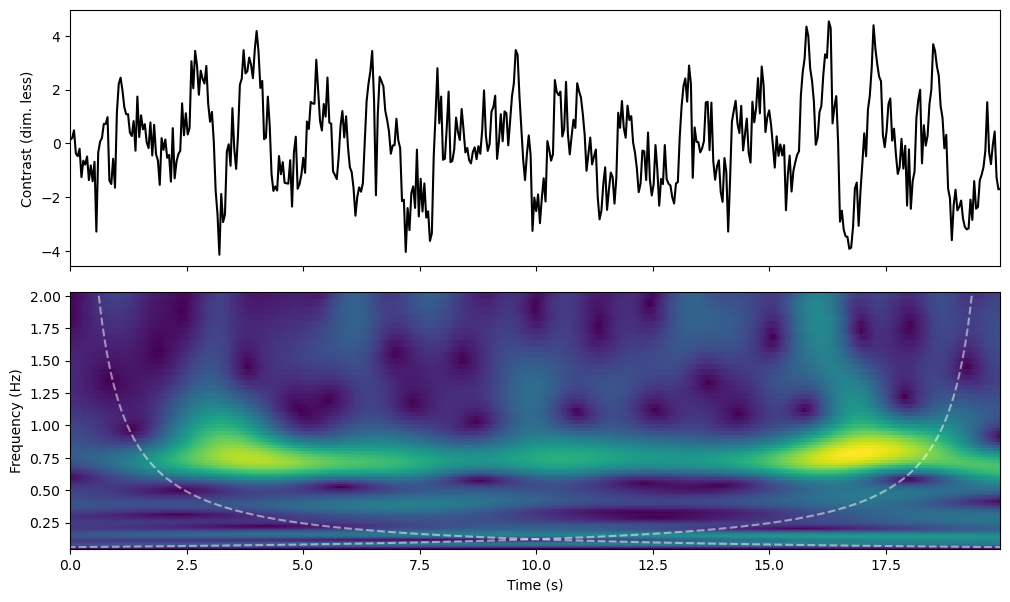

In [358]:
wf.plot_timeseries_and_its_cwt(s, t, 0.05, 2, show_smoothed=False)

In [163]:
s_filt = cs.remove_frequency_band(s, fs, 0.5, 1)

In [164]:
res = cs.fit_ar_model(s_filt, 1)

In [165]:
res

{'result': <statsmodels.tsa.ar_model.AutoRegResultsWrapper at 0x337989950>,
 'intercept': -0.05329987031409363,
 'ar_coeffs': array([0.59807042]),
 'noise_std': 1.0050212814437693,
 'order': 1}

In [166]:
dummy = cs.simulate_ar_surrogate(res, t.size)
frq, pxx = periodogram(dummy, fs)

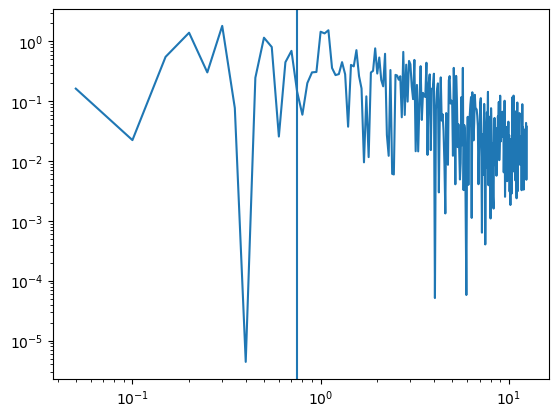

In [167]:
plt.loglog(frq[1:-1], pxx[1:-1])
plt.axvline(0.75)

In [172]:
freqs = np.linspace(0.05, 2, 128)
power, _, scales = cs.compute_cwt_power(s, fs, freqs)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

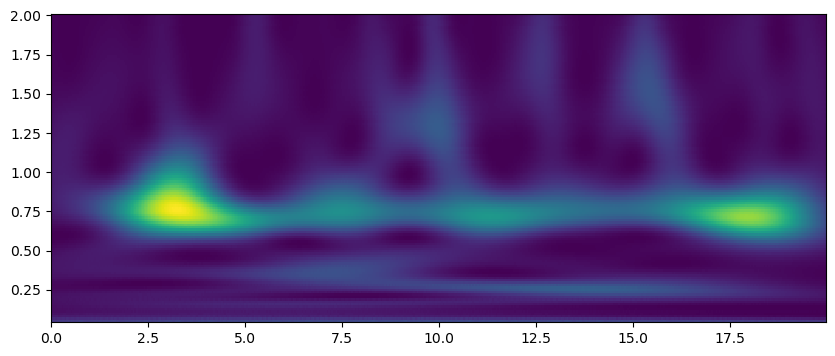

In [173]:
wf.plot_cwt(power, freqs, t)

In [174]:
threshold = cs.monte_carlo_cwt_threshold(
        res,
        n=len(t),
        fs=fs,
        freqs=freqs,
    )

In [175]:
significant = cs.segment_significant_power(power, threshold)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

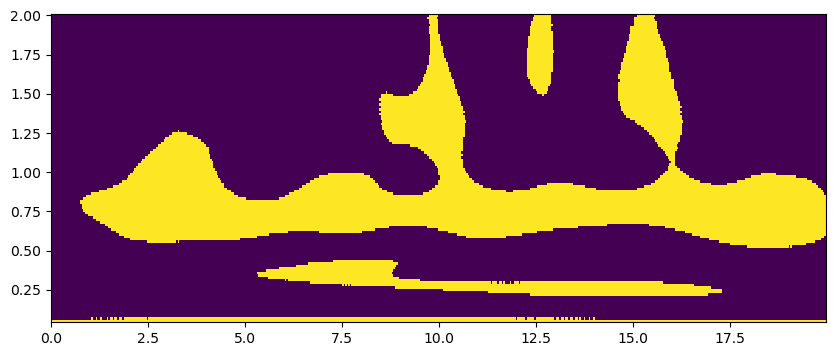

In [176]:
wf.plot_cwt(significant, freqs, t)

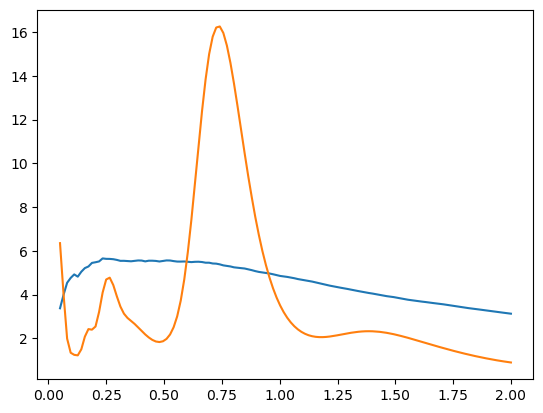

In [177]:
plt.plot(freqs, threshold)
plt.plot(freqs, power.mean(axis=1))

## Data example


In [179]:
import xarray as xr

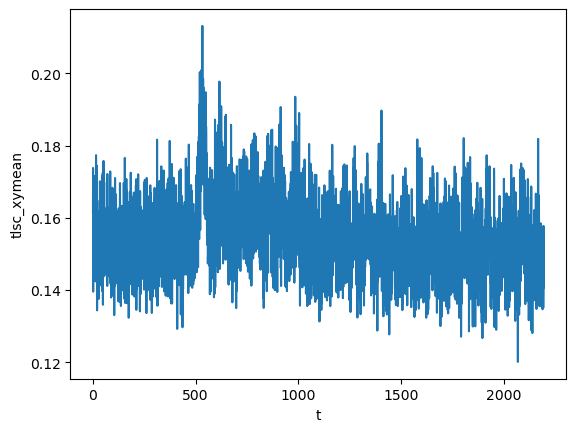

In [317]:
d = xr.open_dataset('../data/20241015a_vehicle_vessel1_REG_INTERP_TimeSeries.nc')
d.tlsc_xymean.plot()

In [318]:
fs=2
s = d.tlsc_xymean.data
t = d.t.data

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

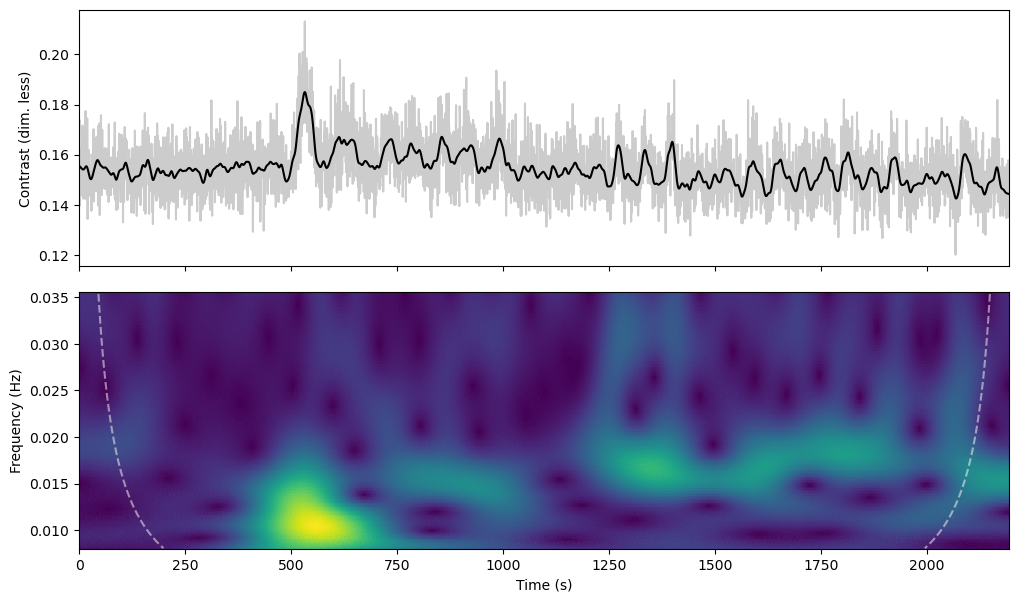

In [329]:
bw = 1.5
cf = 1.3
wf.plot_timeseries_and_its_cwt(s, t, f1=0.008, bandwidth=bw, central_freq=cf, padding_fraction=0.2)

In [330]:
s_filt = cs.remove_frequency_band(s, fs, 0.013, 0.02) # Band

In [331]:
res = cs.fit_ar_model(s_filt, 1)

In [332]:
res

{'result': <statsmodels.tsa.ar_model.AutoRegResultsWrapper at 0x397f052d0>,
 'intercept': 0.1134270136699532,
 'ar_coeffs': array([0.26483427]),
 'noise_std': 0.009598154311766128,
 'order': 1}

In [333]:
dummy = cs.simulate_ar_surrogate(res, t.size)
frq, pxx = periodogram(dummy, fs)

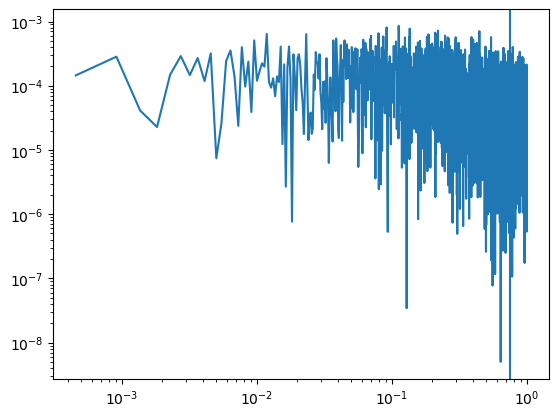

In [334]:
plt.loglog(frq[1:-1], pxx[1:-1])
plt.axvline(0.75)

In [335]:
freqs = np.linspace(0.008, 0.03, 128)
wt = f"cmor{bw}={cf}"

cwt = wf.cwt_with_coi(s, t ,freq_min=freqs[0], freq_max=freqs[-1], bandwidth=bw, central_freq=cf, padding_fraction=0.25)
freqs = cwt.f.data

power = abs(cwt.wt_coefs)**2

In [336]:
ridge = wf.wavelet_ridge(cwt.wt_coefs, cwt.f, cwt.t)

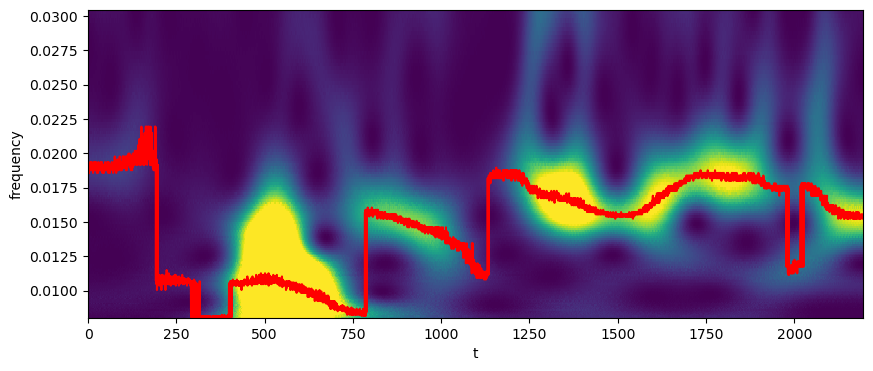

In [337]:
wf.plot_cwt(power, freqs, t, vmax=.001)
ridge.frequency.plot(ax=plt.gca(), color='r')

In [338]:
threshold = cs.monte_carlo_cwt_threshold(
        res,
        n=len(t),
        fs=fs,
        freqs=freqs,
        n_surrogates=10,
        wavelet=wt, 
        pad_fraction=0.25,
        alpha=0.99
    )

In [339]:
significant = cs.segment_significant_power(power, threshold)

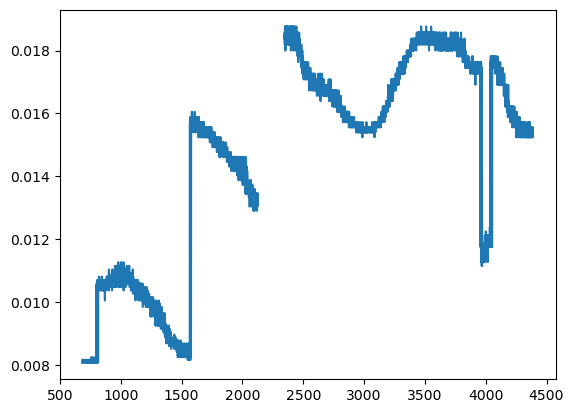

In [355]:
mask_t = significant.sum(axis=0) != False

frq = wf.keep_ridge_inside_mask(significant, ridge.frequency.data, freq_axis=power.f.data)
# frq = ridge.frequency.where(mask_t)

plt.plot(frq)

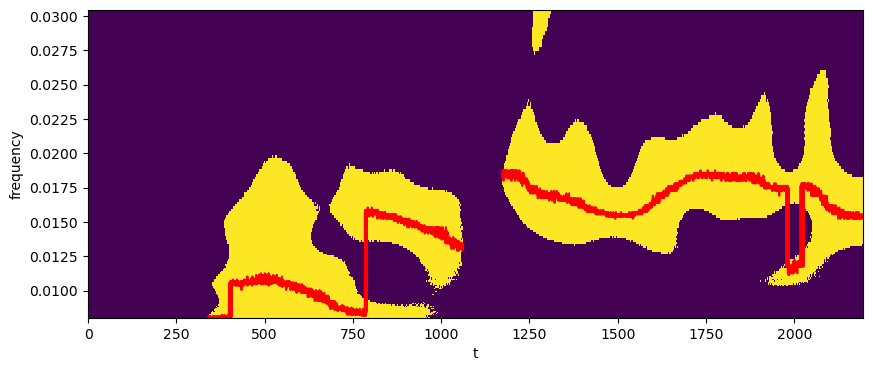

In [341]:
wf.plot_cwt(significant, freqs, t)
frq.plot(ax=plt.gca(), color='r')

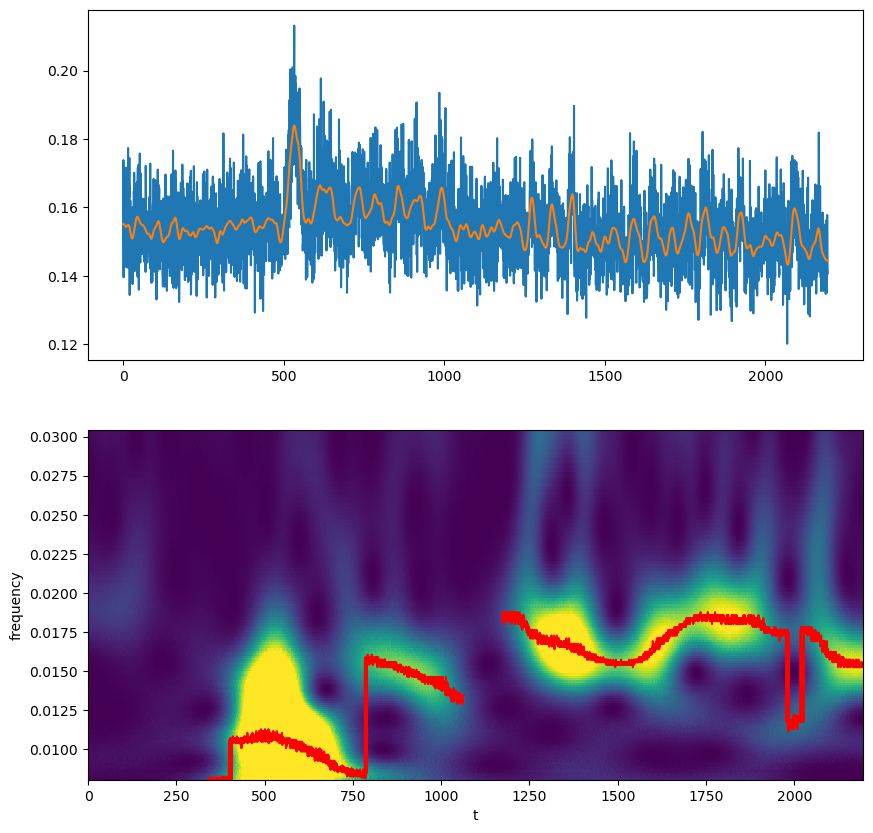

In [342]:
f, (ax,ax1) = plt.subplots(2,1,figsize=(10,10))

ax.plot(t,s)
ax.plot(t, wf.gaussian_filter(s, sigma=9))

wf.plot_cwt(power, freqs, t, vmax=.001, ax=ax1)
frq.plot(color='r', ax=ax1)